## Import the core python libraries used for data analysis

### **`pandas`** help us load and work with tabular data
### `gdown` downloads the dataset from Google Drive.

In [1]:
import pandas as pd
import gdown

## Load the workshop survey dataset into a pandas `DataFrame`

### A `DataFrame` is like a spreadsheet in Python

In [2]:
file_id = "1J424k-xkNvq349TyrD9m2s_iDywrHeds"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "workshop_survey_syn_dataset.csv",
    quiet=False
)

data = pd.read_csv(r'workshop_survey_syn_dataset.csv')

Downloading...
From: https://drive.google.com/uc?id=1J424k-xkNvq349TyrD9m2s_iDywrHeds
To: /content/workshop_survey_syn_dataset.csv
100%|██████████| 440k/440k [00:00<00:00, 32.6MB/s]


# Data quality check

## Before answering any researching, we first `inspect` the dataset.

This helps us understand the `size`, `structure`, `columns`, and `data types` before doing analysis.

### Check the number of rows and columns in the dataset.
### This tells us how many survey responses and variables we are working with.

In [3]:
data.shape

(1000, 9)

### Check the data type of each column.
### This helps us understand whether the data is `text`, `numeric`, or `categorical`.

In [4]:
data.dtypes

,0
participant_id,int64
role,object
department,object
comfort_with_ai,object
main_interest_category,object
main_interest_detail,object
concern_category,object
concern_detail,object
free_text_feedback,object


### **Display** all column names.
### This helps us identify which columns are available for answering our research questions.

In [5]:
data.columns

Index(['participant_id', 'role', 'department', 'comfort_with_ai',
       'main_interest_category', 'main_interest_detail', 'concern_category',
       'concern_detail', 'free_text_feedback'],
      dtype='object')

### **Preview** the first few rows of the dataset.
### This gives us a quick sense of what ***one survey response*** looks like.

In [6]:
data.head()

,participant_id,role,department,comfort_with_ai,main_interest_category,main_interest_detail,concern_category,concern_detail,free_text_feedback
0,837645,Faculty,Public Health,Comfortable,Grant Writing,Improving clarity and turnaround on competitiv...,Hallucinations and Accuracy,Hard to verify AI output accuracy for technica...,"I already use AI fairly regularly, I'd especia..."
1,475133,Undergraduate Student,Education,Neutral,Student Learning Support,Helping Education students use AI tutors witho...,Academic Misconduct,Students using AI to complete Education assign...,"I have mixed feelings about AI, I really want ..."
2,601099,Faculty,Biology,Uncomfortable,Teaching and Course Design,Designing AI-aware assignments and rubrics for...,Copyright and Intellectual Property,Unclear copyright and ownership rules for AI o...,"I've only dabbled with AI and feel uncertain, ..."
3,269917,Research Scientist,Computer Science,Comfortable,Data Analysis,"Cleaning, exploring, and visualizing Computer ...",Data Privacy,Unclear where AI vendors store and reuse our C...,"I already use AI fairly regularly, I'm keen to..."
4,698457,Administrative Staff,Medicine,Neutral,Research Productivity,Cutting time spent on repetitive analysis step...,Data Privacy,Protecting confidential participant and studen...,"I have mixed feelings about AI, I'd love pract..."


## Missing values

Next, we check whether any values are missing or duplicated. In real survey datasets, missing values are common and may need cleaning before analysis.

### **Count missing values** in each column.
#### If a column has many missing values, we would need to decide ***how to handle them*** before analysis.

In [7]:
data.isnull().sum()

,0
participant_id,0
role,0
department,0
comfort_with_ai,0
main_interest_category,0
main_interest_detail,0
concern_category,0
concern_detail,0
free_text_feedback,0


### Check whether there are **duplicate rows** in the dataset.
### Duplicate responses can **manipulate counts and summaries** if they are not intentional.

In [8]:
data.duplicated().sum()

np.int64(0)

In [ ]:
#for x in data.select_dtypes(include="object"):
#    print(data[x].value_counts(dropna=False))

## Analysis

Now that the dataset has been inspected, we begin answering the research questions using **standard notebook-based** analysis.

Count how many participants belong to each role.

This helps us understand who is represented in the survey.

In [9]:
data['role'].value_counts()

,count
role,
Undergraduate Student,251
Graduate Student,197
Faculty,153
Research Staff,78
Administrative Staff,75
Research Scientist,56
Postdoctoral Researcher,51
Academic Advisor,42
IT Staff,36


Count how many participants come from each department.

This gives us a sense of the disciplinary spread of the responses.

In [10]:
data['department'].value_counts()

,count
department,
Public Health,129
Medicine,119
Computer Science,112
Engineering,105
Biology,94
Business,92
Humanities,88
Education,83
Research Computing,43


Count participants by their comfort level with AI.

This gives a high-level view of the audience's readiness for AI-related activities.

In [11]:
data['comfort_with_ai'].value_counts()

,count
comfort_with_ai,
Comfortable,338
Neutral,283
Very Comfortable,204
Uncomfortable,134
Very Uncomfortable,41


## **RQ1:** Who participated in the survey and how AI-comfortable are different groups?

### This research question focuses on audience composition and AI readiness.

Create a **`cross-tabulation`** of role by AI comfort level.

This shows how many people in each role selected each comfort level.

In [12]:
pd.crosstab(data['role'], data['comfort_with_ai'])

comfort_with_ai,Comfortable,Neutral,Uncomfortable,Very Comfortable,Very Uncomfortable
role,,,,,
Academic Advisor,19,8,7,8,0
Academic Leadership,6,8,5,2,0
Administrative Staff,28,16,11,14,6
Department Chair,6,10,1,6,0
Faculty,45,40,32,24,12
Graduate Student,76,55,21,39,6
IT Staff,13,10,3,9,1
Librarian,5,5,2,4,1
Postdoctoral Researcher,13,17,7,11,3


Create the same role-by-comfort table, but normalize by row.

This converts counts into proportions so we can compare roles more fairly.

In [13]:
pd.crosstab(data['role'], data['comfort_with_ai'], normalize="index").round(2)

comfort_with_ai,Comfortable,Neutral,Uncomfortable,Very Comfortable,Very Uncomfortable
role,,,,,
Academic Advisor,0.45,0.19,0.17,0.19,0.00
Academic Leadership,0.29,0.38,0.24,0.10,0.00
Administrative Staff,0.37,0.21,0.15,0.19,0.08
Department Chair,0.26,0.43,0.04,0.26,0.00
Faculty,0.29,0.26,0.21,0.16,0.08
Graduate Student,0.39,0.28,0.11,0.20,0.03
IT Staff,0.36,0.28,0.08,0.25,0.03
Librarian,0.29,0.29,0.12,0.24,0.06
Postdoctoral Researcher,0.25,0.33,0.14,0.22,0.06


Create a **simple bar chart** showing the overall distribution of AI comfort levels.


This gives a quick visual summary of the audience's AI readiness.

<Axes: xlabel='comfort_with_ai'>

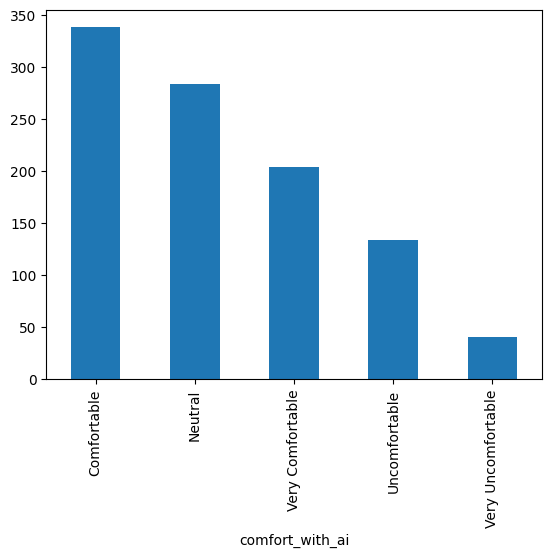

In [14]:
data['comfort_with_ai'].value_counts().plot(kind='bar')

## RQ2: What is participants' AI use case and their concerns attached to their interests?

This research question looks at participant interests and concerns. We first count common interests and concerns, then compare them across roles and interest areas.

### Count the **`detailed AI interests participants`** selected.

This helps us identify the most common use cases participants care about.

In [15]:
data['main_interest_detail'].value_counts()

,count
main_interest_detail,
Understanding governance and compliance needs for campus AI adoption,14
Understanding which generative AI tools actually fit Computer Science workflows,9
Learning to use AI coding assistants for Public Health scripts and tools,8
Creating practice problems and study aids for struggling Education students,8
Speeding up software prototyping and automation in Medicine,8
...,...
Setting expectations and guardrails for AI use across Student Affairs,1
"Cleaning, exploring, and visualizing Sponsored Programs datasets more quickly",1
Comparing chatbots and assistants for practical Education use cases,1


### Count the **`main concern`** categories.


This shows the most common barriers, worries, or risks participants associate with AI use.

In [16]:
data['concern_category'].value_counts()

,count
concern_category,
Data Privacy,130
Academic Misconduct,118
Hallucinations and Accuracy,116
Research Integrity,115
Lack of Training,103
Student Overreliance on AI,103
No Major Concerns,90
Copyright and Intellectual Property,68
Security Risks,42


### Compare `participant role` with `main AI interest` category.


This helps us see whether different groups want AI support for different reasons.

In [17]:
pd.crosstab(data['role'], data['main_interest_category'])

main_interest_category,AI Policy and Governance,Academic Writing,Administrative Efficiency,Career Development,Data Analysis,Generative AI Tools,Grant Writing,Literature Review,Programming Assistance,Research Compliance,Research Computing,Research Productivity,Responsible AI,Student Learning Support,Teaching and Course Design
role,,,,,,,,,,,,,,,
Academic Advisor,0,0,9,11,1,4,1,0,1,0,1,0,3,11,0
Academic Leadership,6,1,3,0,0,3,0,0,0,3,0,0,4,0,1
Administrative Staff,8,1,20,2,0,14,1,1,2,16,1,1,3,5,0
Department Chair,5,1,2,0,0,0,2,1,1,0,0,4,2,0,5
Faculty,1,19,2,3,0,3,39,13,1,1,2,18,9,17,25
Graduate Student,1,30,3,16,32,20,3,36,27,1,1,21,1,4,1
IT Staff,3,0,2,1,0,6,0,0,7,1,8,0,6,1,1
Librarian,3,2,0,1,0,3,0,5,0,0,0,0,0,3,0
Postdoctoral Researcher,3,4,0,4,5,2,11,13,0,0,0,8,0,1,0


### Compare main AI interest category with concern category.

This helps us understand which concerns are connected to which AI use cases.

In [18]:
pd.crosstab(data['main_interest_category'], data['concern_category'])

concern_category,Academic Misconduct,Bias and Fairness,Copyright and Intellectual Property,Cost and Resources,Data Privacy,Hallucinations and Accuracy,Lack of Training,No Major Concerns,Research Compliance,Research Integrity,Security Risks,Student Overreliance on AI
main_interest_category,,,,,,,,,,,,
AI Policy and Governance,2,3,2,5,5,3,4,4,1,0,2,2
Academic Writing,16,2,7,0,8,14,10,14,3,12,0,11
Administrative Efficiency,6,1,6,1,10,3,7,2,4,5,8,4
Career Development,7,1,6,1,8,13,9,5,1,9,1,10
Data Analysis,3,3,6,3,14,13,5,5,4,6,2,4
Generative AI Tools,11,3,5,6,16,7,13,12,0,8,5,13
Grant Writing,12,2,9,6,4,6,7,2,4,16,4,7
Literature Review,12,2,8,2,7,14,3,6,1,15,2,4
Programming Assistance,12,1,4,4,12,19,7,18,2,10,4,7
